In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw5.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 5: Putting it all together 
### Associated lectures: All material till lecture 13 

<div class="alert-warning">
    
## Instructions  
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Before you start  

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W2/syllabus#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
  
- Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions) for detailed guidance on completing and submitting assignments. 

### Group work instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   
### Before submitting  

- **Run all cells** (▶▶ button) to ensure the notebook executes cleanly from top to bottom.

  - Execution counts must start at **1** and be sequential.
    
  - Notebooks with missing outputs or errors may lose marks.

- **Do not upload or push data files** used in this lab to GitHub or Gradescope. (A `.gitignore` is provided to prevent this.)  


### Submitting on Gradescope  

- Upload **only** your `.ipynb` file (with outputs shown) and any required output files. Do **not** submit extra files.
  
- If needed, refer to the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- If your notebook is too large to render, also upload a **Web PDF** or **HTML** version.  
  - You can create one using **File $\rightarrow$ Save and Export Notebook As**.  
  - If you get an error when creating a PDF, try running the following commands in your lab directory:  

    ```bash
    conda install -c conda-forge nbconvert-playwright
    jupyter nbconvert --to webpdf lab1.ipynb
    ```  

  - Ensure all outputs are visible in your PDF or HTML file; TAs cannot grade your work if outputs are missing.

</div>


_Note: Unlike previous assignments, this one is open-ended and project-style. Treat it as an opportunity to explore, experiment, and learn._

<!-- BEGIN QUESTION -->

## Imports

<div class="alert alert-warning">
    
Imports
    
</div>

_Points:_ 0

In [2]:
from hashlib import sha1

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

plt.rcParams["font.size"] = 16

from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
)
from sklearn.metrics import (
    f1_score, roc_auc_score, recall_score, precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb

from scipy.stats import loguniform

In [3]:
import hashlib


def my_sha1(text):
    return hashlib.sha1(text.encode("utf-8")).hexdigest()

<!-- END QUESTION -->

## Introduction

In this homework you will be working on an open-ended mini-project, where you will put all the different things you have learned so far together to solve an interesting problem.

A few notes and tips when you work on this mini-project: 

#### Tips
1. This mini-project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


#### A final note
Finally, this style of this "project" question is different from other assignments. It'll be up to you to decide when you're "done" -- in fact, this is one of the hardest parts of real projects. But please don't spend WAY too much time on this... perhaps "a few hours" (10-14 hours???) is a good guideline for this project . Of course if you're having fun you're welcome to spend as much time as you want! But, if so, try not to do it out of perfectionism or getting the best possible grade. Do it because you're learning and enjoying it. Students from the past cohorts have found such kind of labs useful and fun and I hope you enjoy it as well. 

<br><br>

<!-- BEGIN QUESTION -->

## 1. Pick your problem and explain the prediction problem
<hr>
rubric={points:3}

In this mini project, you have the option to choose on which dataset you will be working on. The tasks you will need to carry on will be similar, independently of your choice.

### Option 1
You can choose to work on a classification problem of predicting whether a credit card client will default or not. 
For this problem, you will use [Default of Credit Card Clients Dataset](https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset). In this data set, there are 30,000 examples and 24 features, and the goal is to estimate whether a person will default (fail to pay) their credit card bills; this column is labeled "default.payment.next.month" in the data. The rest of the columns can be used as features. You may take some ideas and compare your results with [the associated research paper](https://www.sciencedirect.com/science/article/pii/S0957417407006719), which is available through [the UBC library](https://www.library.ubc.ca/). 


### Option 2
You can choose to work on a regression problem using a [dataset](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data) of New York City Airbnb listings from 2019. As usual, you'll need to start by downloading the dataset, then you will try to predict `reviews_per_month`, as a proxy for the popularity of the listing. Airbnb could use this sort of model to predict how popular future listings might be before they are posted, perhaps to help guide hosts create more appealing listings. In reality they might instead use something like vacancy rate or average rating as their target, but we do not have that available here.

> Note there is an updated version of this dataset with more features available [here](http://insideairbnb.com/). The features were are using in `listings.csv.gz` for the New York city datasets. You will also see some other files like `reviews.csv.gz`. For your own interest you may want to explore the expanded dataset and try your analysis there. However, please submit your results on the dataset obtained from Kaggle.


<div class="alert alert-info">
    
**Your tasks:**

1. Review the available datasets and choose the one you find most interesting. It may help to read through the dataset documentation on Kaggle before deciding.
2. Once you've selected a dataset, take time to understand the problem it represents and the meaning of each feature. Use the Kaggle documentation to guide you.
3. Download the dataset and load it into a pandas DataFrame.
4. Write a few sentences summarizing your initial thoughts about the problem and the dataset.
   
</div>

<div class="alert alert-warning">
    
Solution_1
    
</div>

_Points:_ 3

## Option 1 - Default of Credit Card Clients Dataset

This is an imbalanced binary classification problem where the accuracy metric is probably misleading. We'd rather use F1-score, AUC-ROC or precision-recall as evaluation criteria. The most predictive features are likely the PAY repayment status columns, since clients who are already 2+ months late are strongly predictive of future defaults.

### There are 25 variables:

- **ID**: ID of each client  
- **LIMIT_BAL**: Amount of given credit in NT dollars (includes individual and family/supplementary credit)  
- **SEX**: Gender (1=male, 2=female)  
- **EDUCATION**: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)  
- **MARRIAGE**: Marital status (1=married, 2=single, 3=others)  
- **AGE**: Age in years  
- **PAY_0**: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)  
- **PAY_2**: Repayment status in August, 2005 (scale same as above)  
- **PAY_3**: Repayment status in July, 2005 (scale same as above)  
- **PAY_4**: Repayment status in June, 2005 (scale same as above)  
- **PAY_5**: Repayment status in May, 2005 (scale same as above)  
- **PAY_6**: Repayment status in April, 2005 (scale same as above)  
- **BILL_AMT1**: Amount of bill statement in September, 2005 (NT dollar)  
- **BILL_AMT2**: Amount of bill statement in August, 2005 (NT dollar)  
- **BILL_AMT3**: Amount of bill statement in July, 2005 (NT dollar)  
- **BILL_AMT4**: Amount of bill statement in June, 2005 (NT dollar)  
- **BILL_AMT5**: Amount of bill statement in May, 2005 (NT dollar)  
- **BILL_AMT6**: Amount of bill statement in April, 2005 (NT dollar)  
- **PAY_AMT1**: Amount of previous payment in September, 2005 (NT dollar)  
- **PAY_AMT2**: Amount of previous payment in August, 2005 (NT dollar)  
- **PAY_AMT3**: Amount of previous payment in July, 2005 (NT dollar)  
- **PAY_AMT4**: Amount of previous payment in June, 2005 (NT dollar)  
- **PAY_AMT5**: Amount of previous payment in May, 2005 (NT dollar)  
- **PAY_AMT6**: Amount of previous payment in April, 2005 (NT dollar)  
- **default.payment.next.month**: Default payment (1=yes, 0=no)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

<div class="alert alert-warning">
    
Solution_2
    
</div>

_Points:_ 2

In [4]:
# Load data
data = pd.read_csv("data/UCI_Credit_Card.csv")

# Split data 80/20
X = data.drop(columns=["default.payment.next.month"])
y = data["default.payment.next.month"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

# Clean EDUCATION/MARRIAGE
X_train["EDUCATION"] = X_train["EDUCATION"].replace({0: 4, 5: 4, 6: 4})  # 0,5,6 → 4 (other/unknown)
X_train["MARRIAGE"] = X_train["MARRIAGE"].replace({0: 3})                # 0 → 3 (other/unknown)
X_test["EDUCATION"] = X_test["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
X_test["MARRIAGE"] = X_test["MARRIAGE"].replace({0: 3})

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
rubric={points:10}

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

<div class="alert alert-warning">
    
Solution_3
    
</div>

_Points:_ 10

### Summary of the initial EDA

The dataset shows a 22.3% default rate with moderate class imbalance. Payment history (PAY_0–PAY_6) is the strongest predictor. Delaying payments by 2+ months increases default risk to 70%+, while paying duly keeps risk at ~13%. Credit limit inversely correlates with default risk, dropping from 35% for low-limit customers to 11% for high-limit ones. Demographics show weaker but notable patterns: males, high school graduates, and older customers (60+) default more frequently. Surprisingly, bill and payment amounts correlate weakly with default, suggesting timeliness matters more than dollar amounts.

### Select evaluation metrics

For this credit default prediction problem with 22.3% class imbalance, I recommend:

**1. ROC-AUC**: It evaluates the model's ability to distinguish between classes across all thresholds and is robust to class imbalance. Essential for credit scoring where you need good ranking of risk scores.

**2. Recall (Sensitivity)**: We want to catch as many actual defaulters as possible. Missing a defaulter (false negative) is typically more costly than incorrectly flagging a good customer.

**3. F1-Score**: Balances precision and recall, useful when you need a single metric that accounts for both false positives (wrongly rejecting good customers) and false negatives (approving risky customers).

In [5]:
# Combine features and target for convenience
train_df = X_train.copy()
train_df["default.payment.next.month"] = y_train

In [6]:
# Basic structure
print("Training feature shape:", X_train.shape)
print("Test feature shape:", X_test.shape)
print("\nFirst 5 rows of training data:")
display(train_df.head())

Training feature shape: (24000, 24)
Test feature shape: (6000, 24)

First 5 rows of training data:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
19682,19683,200000.0,2,2,1,46,0,0,0,0,...,103422.0,95206.0,65108.0,3692.0,5000.0,3300.0,2500.0,2930.0,1500.0,0
11062,11063,120000.0,2,1,1,32,-1,-1,-1,-1,...,476.0,802.0,326.0,652.0,326.0,476.0,802.0,0.0,326.0,1
197,198,20000.0,2,1,2,22,0,0,0,0,...,8332.0,18868.0,19247.0,1500.0,1032.0,541.0,20000.0,693.0,1000.0,0
23620,23621,100000.0,2,4,2,34,0,0,0,0,...,23181.0,7721.0,3219.0,5004.0,3811.0,3002.0,4000.0,3219.0,1864.0,0
26031,26032,290000.0,2,2,2,29,0,0,0,0,...,8770.0,9145.0,10016.0,1130.0,1502.0,1300.0,500.0,1000.0,1001.0,0


In [7]:
target_col = "default.payment.next.month"

# Numeric summary statistics
print("\nSummary statistics for numeric features:")
display(train_df.describe().T)

# Default rate overall
print("\nOverall default rate in the training set:")
default_rate = y_train.mean()
print(f"Default rate: {default_rate:.3f}")

# Default rate by SEX
print("\nDefault rate by SEX (1 = male, 2 = female):")
default_by_sex = (
    train_df
    .groupby("SEX")[target_col]
    .mean()
    .rename("default_rate")
)
display(default_by_sex)

# Default rate by EDUCATION
print(
    "\nDefault rate by EDUCATION "
    "(1 = graduate school, 2 = university, 3 = high school, "
    "4 = others):"
)
default_by_edu = (
    train_df
    .groupby("EDUCATION")[target_col]
    .mean()
    .rename("default_rate")
)
display(default_by_edu)

# Default rate by MARRIAGE
print(
    "\nDefault rate by MARRIAGE "
    "(1 = married, 2 = single, 3 = others):"
)
default_by_marriage = (
    train_df
    .groupby("MARRIAGE")[target_col]
    .mean()
    .rename("default_rate")
)
display(default_by_marriage)

# Default rate by AGE bands
print(
    "\nDefault rate by AGE band "
    "(20–29, 30–39, 40–49, 50–59, 60+):"
)
age_bins = [20, 30, 40, 50, 60, 80]
age_labels = ["20–29", "30–39", "40–49", "50–59", "60+"]

train_df["AGE_band"] = pd.cut(
    train_df["AGE"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

default_by_age_band = (
    train_df
    .groupby("AGE_band", observed=False)[target_col]
    .mean()
    .rename("default_rate")
)
display(default_by_age_band)

# Default rate by credit limit LIMIT_BAL bands
print("\nDefault rate by LIMIT_BAL band (NT$):")
limit_bins = [0, 50000, 100000, 200000, 500000, 1000000]
limit_labels = ["≤50k", "50k–100k", "100k–200k", "200k–500k", "500k+"]

train_df["LIMIT_BAL_band"] = pd.cut(
    train_df["LIMIT_BAL"],
    bins=limit_bins,
    labels=limit_labels,
    right=False
)

default_by_limit = (
    train_df
    .groupby("LIMIT_BAL_band", observed=False)[target_col]
    .mean()
    .rename("default_rate")
)
display(default_by_limit)

# Default rate by PAY_0 (repayment status Sept 2005: -1=pay duly, 1+=months delayed)
print("\nDefault rate by PAY_0 (repayment status in September 2005):")
default_by_pay0 = (
    train_df
    .groupby("PAY_0")[target_col]
    .mean()
    .rename("default_rate")
)
display(default_by_pay0)


Summary statistics for numeric features:


,count,mean,std,min,25%,50%,75%,max
ID,24000.0,14964.174292,8660.479272,1.0,7467.75,14975.0,22460.25,30000.0
LIMIT_BAL,24000.0,167893.486667,130109.666875,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,24000.0,1.603125,0.489260,1.0,1.00,2.0,2.00,2.0
EDUCATION,24000.0,1.841000,0.744586,1.0,1.00,2.0,2.00,4.0
MARRIAGE,24000.0,1.558000,0.520958,1.0,1.00,2.0,2.00,3.0
AGE,24000.0,35.488458,9.217424,21.0,28.00,34.0,41.00,79.0
PAY_0,24000.0,-0.017542,1.125331,-2.0,-1.00,0.0,0.00,8.0
PAY_2,24000.0,-0.135292,1.199812,-2.0,-1.00,0.0,0.00,8.0
PAY_3,24000.0,-0.170042,1.201709,-2.0,-1.00,0.0,0.00,8.0
PAY_4,24000.0,-0.224292,1.170630,-2.0,-1.00,0.0,0.00,8.0



Overall default rate in the training set:
Default rate: 0.222

Default rate by SEX (1 = male, 2 = female):


SEX
1    0.244619
2    0.207392
Name: default_rate, dtype: float64


Default rate by EDUCATION (1 = graduate school, 2 = university, 3 = high school, 4 = others):


...

AGE_band
20–29    0.227675
30–39    0.205601
40–49    0.228467
50–59    0.250936
60+      0.296703
Name: default_rate, dtype: float64


Default rate by LIMIT_BAL band (NT$):


LIMIT_BAL_band
≤50k         0.354707
50k–100k     0.261083
100k–200k    0.211066
200k–500k    0.157663
500k+        0.110372
Name: default_rate, dtype: float64


Default rate by PAY_0 (repayment status in September 2005):


PAY_0
-2    0.136967
-1    0.169852
 0    0.128320
 1    0.341273
 2    0.694787
 3    0.750943
 4    0.666667
 5    0.500000
 6    0.444444
 7    0.777778
 8    0.562500
Name: default_rate, dtype: float64

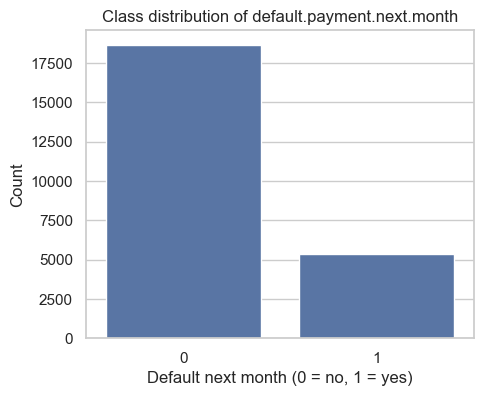

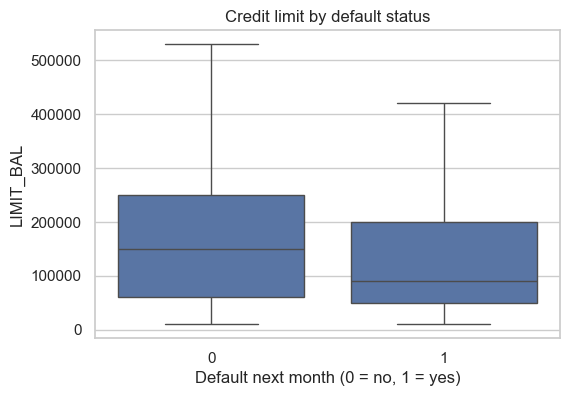

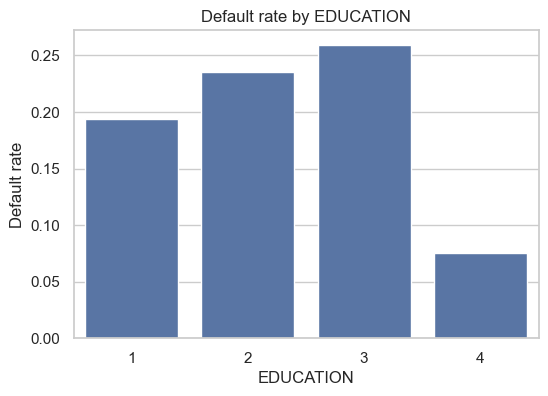

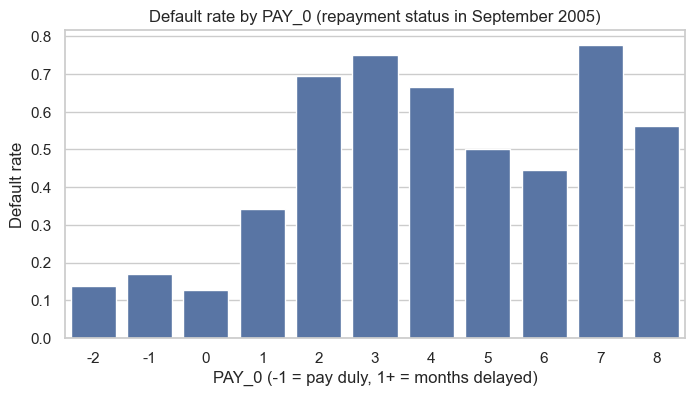

In [8]:
# Visualizations

sns.set_theme(style="whitegrid")

# Class balance of the target
plt.figure(figsize=(5, 4))
sns.countplot(x=target_col, data=train_df)
plt.title("Class distribution of default.payment.next.month")
plt.xlabel("Default next month (0 = no, 1 = yes)")
plt.ylabel("Count")
plt.show()

# Distribution of credit limit by default status
plt.figure(figsize=(6, 4))
sns.boxplot(
    x=target_col,
    y="LIMIT_BAL",
    data=train_df,
    showfliers=False
)
plt.title("Credit limit by default status")
plt.xlabel("Default next month (0 = no, 1 = yes)")
plt.ylabel("LIMIT_BAL")
plt.show()

# Default rate by EDUCATION
plt.figure(figsize=(6, 4))
edu_default = (
    train_df
    .groupby("EDUCATION")[target_col]
    .mean()
    .reset_index(name="default_rate")
)
sns.barplot(x="EDUCATION", y="default_rate", data=edu_default)
plt.title("Default rate by EDUCATION")
plt.ylabel("Default rate")
plt.show()

# Default rate by PAY_0 (repayment status Sept 2005: -1=pay duly, 1+=months delayed)
plt.figure(figsize=(8, 4))
pay0_default = (
    train_df
    .groupby("PAY_0")[target_col]
    .mean()
    .reset_index(name="default_rate")
)
sns.barplot(x="PAY_0", y="default_rate", data=pay0_default)
plt.title("Default rate by PAY_0 (repayment status in September 2005)")
plt.xlabel("PAY_0 (-1 = pay duly, 1+ = months delayed)")
plt.ylabel("Default rate")
plt.show()


Correlation of numeric features with the target:


default.payment.next.month    1.000000
PAY_0                         0.321147
PAY_2                         0.262853
PAY_3                         0.237689
PAY_4                         0.217307
PAY_5                         0.206877
PAY_6                         0.192620
EDUCATION                     0.037799
AGE                           0.015458
BILL_AMT6                    -0.002472
BILL_AMT5                    -0.003684
BILL_AMT4                    -0.007784
BILL_AMT2                    -0.010814
BILL_AMT3                    -0.010888
ID                           -0.013651
BILL_AMT1                    -0.017134
MARRIAGE                     -0.025446
SEX                          -0.043814
PAY_AMT5                     -0.051887
PAY_AMT6                     -0.053467
PAY_AMT4                     -0.056611
PAY_AMT3                     -0.059640
PAY_AMT2                     -0.063183
PAY_AMT1                     -0.070152
LIMIT_BAL                    -0.149947
Name: default.payment.nex

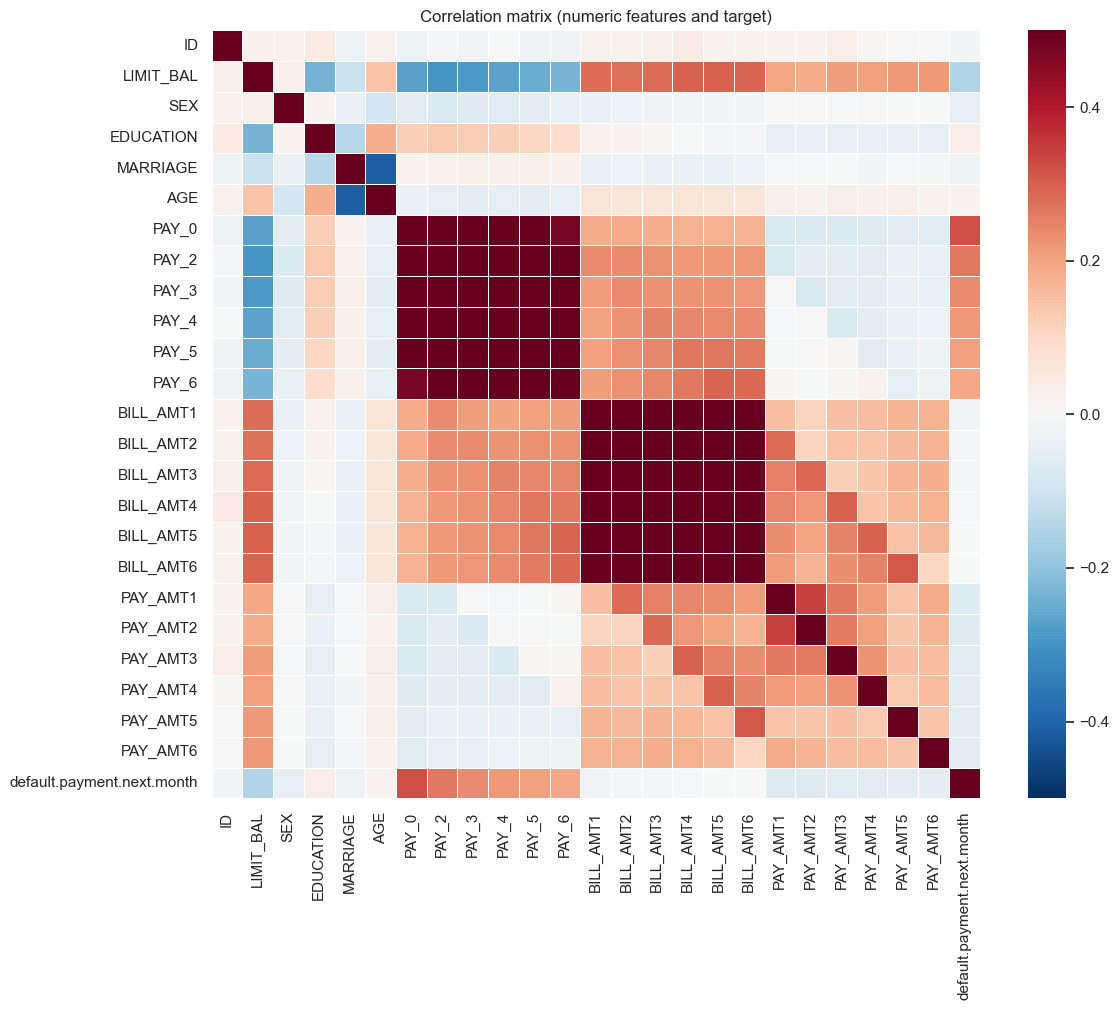

In [9]:
# Correlation with the target
corr_with_target = (
    train_df.corr(numeric_only=True)[target_col]
    .sort_values(ascending=False)
)
print("\nCorrelation of numeric features with the target:")
display(corr_with_target)

# Correlation matrix including target
plt.figure(figsize=(12, 10))
numeric_cols = train_df.select_dtypes(include=[np.number])
sns.heatmap(
    numeric_cols.corr(),
    annot=False,
    cmap="RdBu_r",
    center=0,
    vmin=-0.5,
    vmax=0.5,
    square=True,
    linewidths=0.5,
)
plt.title("Correlation matrix (numeric features and target)")
plt.tight_layout()
plt.show()

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

<div class="alert alert-warning">
    
Solution_4
    
</div>

_Points:_ 1

## Engineered Features

- `utilization_avg`: The customer’s **average credit utilization across 6 months**, computed from total bill amount divided by total available credit. This captures how heavily they typically use their credit line.
- `utilization_max`: The **highest single-month utilization ratio** over the 6 months. This flags customers who may have had at least one period of unusually high borrowing pressure.
- `utilization_trend`: The **change in bill amount from month 6 to month 1**, scaled by credit limit. This captures whether debt is generally growing or shrinking over time.
- `payment_coverage_avg`: The **average fraction of each month’s bill that was covered by payment**. Higher values mean the client is generally paying off more of what they owe.
- `months_delayed`: The **number of months with a positive repayment delay status**. This is a direct count of how often the client was late.
- `max_delay_months`: The **worst repayment delay observed** across the 6 status columns. This captures the most severe delinquency episode.
- `delinquency_streak`: The **longest consecutive run of delayed-payment months**. This is useful because repeated late payments are often more informative than isolated ones.
- `over_limit_count`: The **number of months where the bill exceeded the credit limit**. This reflects how often the client appeared financially overextended.
- `bill_momentum`: The **average month-to-month bill change** based on the difference between the most recent and oldest bill amounts. This measures whether balances are building up or easing off.
- `total_outstanding`: The **total billed amount minus total paid amount** across the 6 months. This estimates the client’s overall unpaid burden.
- `delay_x_limit`: An **interaction feature** equal to worst delay times credit limit. This tries to capture the idea that severe delinquency may mean something different for larger-credit clients than for smaller-credit clients.

In [10]:
# Store original columns for comparison later
original_cols = X_train.columns.tolist()

In [11]:
# Credit Utilization Features
bill_amt_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]

for df in [X_train, X_test]:
    df["utilization_avg"] = (
        df[bill_amt_cols].sum(axis=1) / (6 * df["LIMIT_BAL"])
    ).replace([np.inf, -np.inf], 0).fillna(0)

    df["utilization_max"] = (
        df[bill_amt_cols].div(df["LIMIT_BAL"], axis=0).max(axis=1)
    ).replace([np.inf, -np.inf], 0).fillna(0)

    df["utilization_trend"] = (
        (df["BILL_AMT1"] - df["BILL_AMT6"]) / df["LIMIT_BAL"]
    ).replace([np.inf, -np.inf], 0).fillna(0)

In [12]:
# Payment Behavior Features
pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
pay_amt_cols    = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

for df in [X_train, X_test]:
    df["payment_coverage_avg"] = (
        (df["PAY_AMT1"] / (df["BILL_AMT1"] + 1)) +
        (df["PAY_AMT2"] / (df["BILL_AMT2"] + 1)) +
        (df["PAY_AMT3"] / (df["BILL_AMT3"] + 1)) +
        (df["PAY_AMT4"] / (df["BILL_AMT4"] + 1)) +
        (df["PAY_AMT5"] / (df["BILL_AMT5"] + 1)) +
        (df["PAY_AMT6"] / (df["BILL_AMT6"] + 1))
    ) / 6
    df["payment_coverage_avg"] = df["payment_coverage_avg"].replace([np.inf, -np.inf], 0).fillna(0).clip(0, 5.0)
    delayed_flags = (df[pay_status_cols] > 0).astype(int)
    streaks = delayed_flags.to_numpy(copy=True)
    for i in range(1, streaks.shape[1]):
        streaks[:, i] = (streaks[:, i - 1] + 1) * streaks[:, i]
    df["months_delayed"] = delayed_flags.sum(axis=1)
    df["max_delay_months"] = df[pay_status_cols].max(axis=1)
    df["delinquency_streak"] = streaks.max(axis=1)
    df["over_limit_count"] = df[bill_amt_cols].gt(df["LIMIT_BAL"], axis=0).sum(axis=1)

In [13]:
# Financial Trajectory Features
for df in [X_train, X_test]:
    df["bill_momentum"]     = (df["BILL_AMT1"] - df["BILL_AMT6"]) / 6
    df["total_outstanding"] = df[bill_amt_cols].sum(axis=1) - df[pay_amt_cols].sum(axis=1)

In [14]:
# Interaction Feature
for df in [X_train, X_test]:
    df["delay_x_limit"] = df["max_delay_months"] * df["LIMIT_BAL"]

In [15]:
# Summary
new_features = [c for c in X_train.columns if c not in original_cols]
print(f"Original features: {len(original_cols)}")
print(f"New features added: {len(new_features)}")
print(f"Total features: {X_train.shape[1]}")
print(f"\nNew features: {new_features}")

X_train[new_features].describe()

Original features: 24
New features added: 11
Total features: 35

New features: ['utilization_avg', 'utilization_max', 'utilization_trend', 'payment_coverage_avg', 'months_delayed', 'max_delay_months', 'delinquency_streak', 'over_limit_count', 'bill_momentum', 'total_outstanding', 'delay_x_limit']


,utilization_avg,utilization_max,utilization_trend,payment_coverage_avg,months_delayed,max_delay_months,delinquency_streak,over_limit_count,bill_momentum,total_outstanding,delay_x_limit
count,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,2.400000e+04,2.400000e+04
mean,0.371969,0.494252,0.106664,1.069135,0.828250,0.437250,0.789292,0.277333,2059.996806,2.377320e+05,2.184425e+04
std,0.352206,0.435042,0.303383,1.760229,1.548634,1.349218,1.507146,0.874281,7287.233632,3.631204e+05,2.536356e+05
min,-0.200154,-0.100000,-1.827300,0.000000,0.000000,-2.000000,0.000000,0.000000,-71465.166667,-2.671514e+06,-1.560000e+06
25%,0.029722,0.069734,-0.028631,0.039280,0.000000,0.000000,0.000000,0.000000,-492.875000,4.571750e+03,0.000000e+00
50%,0.281567,0.426864,0.007049,0.078053,0.000000,0.000000,0.000000,0.000000,161.500000,1.016850e+05,0.000000e+00
75%,0.686101,0.923319,0.184517,1.169395,1.000000,2.000000,1.000000,0.000000,3305.666667,3.034775e+05,1.000000e+05
max,5.364308,10.688575,5.309500,5.000000,6.000000,8.000000,6.000000,6.000000,86433.666667,4.116080e+06,3.480000e+06


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

### Feature Type Classification

#### 1. **Numerical Features (Continuous)**
| Feature | Transformation | Rationale |
|---------|----------------|-----------|
| `LIMIT_BAL`, `BILL_AMT1-6`, `PAY_AMT1-6` | StandardScaler | Monetary amounts on different scales |
| `AGE` | StandardScaler | Already reasonable range |
| `utilization_avg`, `utilization_max`, `utilization_trend` | StandardScaler | Ratios, well-behaved |
| `bill_momentum`, `total_outstanding` | RobustScaler | Large range, potential outliers |
| `delay_x_limit` | StandardScaler | Interaction term, large magnitudes |

#### 2. **Numerical with Outliers (Needs Special Handling)**
| Feature | Transformation | Rationale |
|---------|----------------|-----------|
| `payment_coverage_avg` | Clip at 99th percentile (or 5.0), then StandardScaler | Extreme outliers (max 83,050) from zero-bill divisions |

#### 3. **Ordinal Features (treated as numeric)**
| Feature | Transformation | Rationale |
|---------|----------------|-----------|
| `PAY_0` through `PAY_6` (-2 to 8+) | StandardScaler | Numeric ordinal; scaled for compatibility with linear models |
| `months_delayed`, `max_delay_months`, `delinquency_streak`, `over_limit_count` | StandardScaler | Count-based aggregates that summarize repayment severity and credit overextension |

#### 4. **Binary/Categorical Features**
| Feature | Transformation | Rationale |
|---------|----------------|-----------|
| `SEX` (1=male, 2=female) | OneHotEncoder(drop='if_binary') | Binary variable |
| `MARRIAGE` (1=married, 2=single, 3=other) | OneHotEncoder | 3 categories, no inherent order |
| `EDUCATION` (1=grad, 2=uni, 3=high, 4=other) | OneHotEncoder | Category 4 (others/unknown) doesn't fit a clean ordinal hierarchy, so one-hot encoding is preferred |

#### 5. **Identifier (Drop)**
| Feature | Action | Rationale |
|---------|--------|-----------|
| `ID` | Drop | No predictive value |

<div class="alert alert-warning">
    
Solution_5
    
</div>

_Points:_ 10

In [16]:
# Drop: ID has no predictive value
drop_features = ["ID"]

# StandardScaler: Monetary amounts, well-behaved ratios, and clipped payment coverage
standard_numeric = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "months_delayed", "max_delay_months", "delinquency_streak", "over_limit_count",
    "utilization_avg", "utilization_max", "utilization_trend",
    "payment_coverage_avg",
    "delay_x_limit",
]

# RobustScaler: Features with outliers
robust_numeric = ["bill_momentum", "total_outstanding"]

# OneHotEncoder: Categorical features
categorical_features = ["SEX", "MARRIAGE", "EDUCATION"]

In [17]:
# Define ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("drop", "drop", drop_features),
        ("standard_scaler", StandardScaler(), standard_numeric),
        ("robust_scaler", RobustScaler(), robust_numeric),
        ("onehot", OneHotEncoder(drop="if_binary", sparse_output=False), categorical_features),
    ],
    remainder="drop"
)

In [18]:
# Fit on training data, transform both train and test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# Get feature names after transformation
feature_names = preprocessor.get_feature_names_out()

print(f"Features before preprocessing: {X_train.shape[1]}")
print(f"Features after preprocessing: {X_train_processed.shape[1]}")
print(f"\nFeature names: {feature_names}")

Features before preprocessing: 35
Features after preprocessing: 39

Feature names: ['standard_scaler__LIMIT_BAL' 'standard_scaler__AGE'
 'standard_scaler__BILL_AMT1' 'standard_scaler__BILL_AMT2'
 'standard_scaler__BILL_AMT3' 'standard_scaler__BILL_AMT4'
 'standard_scaler__BILL_AMT5' 'standard_scaler__BILL_AMT6'
 'standard_scaler__PAY_AMT1' 'standard_scaler__PAY_AMT2'
 'standard_scaler__PAY_AMT3' 'standard_scaler__PAY_AMT4'
 'standard_scaler__PAY_AMT5' 'standard_scaler__PAY_AMT6'
 'standard_scaler__PAY_0' 'standard_scaler__PAY_2'
 'standard_scaler__PAY_3' 'standard_scaler__PAY_4'
 'standard_scaler__PAY_5' 'standard_scaler__PAY_6'
 'standard_scaler__months_delayed' 'standard_scaler__max_delay_months'
 'standard_scaler__delinquency_streak' 'standard_scaler__over_limit_count'
 'standard_scaler__utilization_avg' 'standard_scaler__utilization_max'
 'standard_scaler__utilization_trend'
 'standard_scaler__payment_coverage_avg' 'standard_scaler__delay_x_limit'
 'robust_scaler__bill_momentum' 'r

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

<div class="alert alert-warning">
    
Solution_6
    
</div>

_Points:_ 2

In [19]:
# Create baseline model (always predicts majority class)
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=123)

# Evaluate with cross-validation using F1, ROC-AUC, Recall
dummy_scores = cross_validate(
    dummy_clf, 
    X_train_processed, 
    y_train, 
    cv=10, 
    scoring=["f1", "roc_auc", "recall"],
    return_train_score=True
)

In [20]:
# Display results
print("DummyClassifier (Most Frequent) - Baseline Results:")
print(f"F1-Score:     {dummy_scores['test_f1'].mean():.4f} (+/- {dummy_scores['test_f1'].std():.4f})")
print(f"ROC-AUC:      {dummy_scores['test_roc_auc'].mean():.4f} (+/- {dummy_scores['test_roc_auc'].std():.4f})")
print(f"Recall:       {dummy_scores['test_recall'].mean():.4f} (+/- {dummy_scores['test_recall'].std():.4f})")

DummyClassifier (Most Frequent) - Baseline Results:
F1-Score:     0.0000 (+/- 0.0000)
ROC-AUC:      0.5000 (+/- 0.0000)
Recall:       0.0000 (+/- 0.0000)


In [21]:
# For reference later on
print(f"\nClass distribution in training set:")
print(f"Non-default (0): {(y_train == 0).mean():.3f}")
print(f"Default (1):     {(y_train == 1).mean():.3f}")


Class distribution in training set:
Non-default (0): 0.778
Default (1):     0.222


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

<div class="alert alert-warning">
    
Solution_7
    
</div>

_Points:_ 10

### Summary

Logistic regression with balanced class weights achieves CV F1-score of 0.53 and ROC-AUC of 0.76. Hyperparameter tuning selected C=0.057 (strong regularization), yet train and CV scores are nearly identical, indicating the model is underfitting. The linear decision boundary is insufficient for this dataset. A non-linear model is likely needed.

Tuning improved CV F1 only slightly (0.5296 → 0.5303), which reinforces that the linear model is hitting a ceiling.

In [22]:
scoring = ["f1", "roc_auc", "recall"]

# Cross-validation with default C to understand baseline linear performance
lr_default = make_pipeline(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=123)
)

default_scores = cross_validate(
    lr_default, X_train_processed, y_train,
    cv=10, scoring=scoring, return_train_score=True
)

print("LogisticRegression (default C=1.0):")
for metric in scoring:
    print(f"  {metric:8s}: {default_scores[f'test_{metric}'].mean():.4f} (+/- {default_scores[f'test_{metric}'].std():.4f})")

LogisticRegression (default C=1.0):
  f1      : 0.5264 (+/- 0.0162)
  roc_auc : 0.7607 (+/- 0.0125)
  recall  : 0.6180 (+/- 0.0195)


In [23]:
# Hyperparameter tuning over C
param_dist = {"logisticregression__C": loguniform(1e-4, 1e7)}

lr_pipe = make_pipeline(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=123)
)

random_search = RandomizedSearchCV(
    lr_pipe,
    param_distributions=param_dist,
    n_iter=50,
    cv=10,
    scoring="f1",
    refit=True,
    random_state=123,
    n_jobs=-1,
    return_train_score=True,
)

random_search.fit(X_train_processed, y_train)

print(f"Best C:       {random_search.best_params_['logisticregression__C']:.5f}")
print(f"Best CV F1:   {random_search.best_score_:.4f}")

Best C:       26.94859
Best CV F1:   0.5265


In [24]:
# Evaluate best model across all metrics
best_lr = random_search.best_estimator_

tuned_scores = cross_validate(
    best_lr, X_train_processed, y_train,
    cv=10, scoring=scoring, return_train_score=True
)

print("LogisticRegression (tuned):")
for metric in scoring:
    train = tuned_scores[f'train_{metric}'].mean()
    test  = tuned_scores[f'test_{metric}'].mean()
    std   = tuned_scores[f'test_{metric}'].std()
    print(f"  {metric:8s}  train={train:.4f}  CV={test:.4f} (+/- {std:.4f})")

LogisticRegression (tuned):
  f1        train=0.5272  CV=0.5265 (+/- 0.0160)
  roc_auc   train=0.7635  CV=0.7607 (+/- 0.0126)
  recall    train=0.6197  CV=0.6178 (+/- 0.0191)


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

<div class="alert alert-warning">
    
Solution_8
    
</div>

_Points:_ 12

### Summary

| Model | F1 CV | ROC-AUC CV | Recall CV | Fit Time |
|---|---:|---:|---:|---:|
| LogisticReg | 0.5265 | 0.7607 | 0.6178 | 0.05s |
| CatBoost | 0.5402 | 0.7862 | 0.6431 | 2.61s |
| RandomForest | 0.5444 | 0.7806 | 0.5600 | 0.48s |
| HistGradBoost | 0.5408 | 0.7855 | 0.6243 | 0.53s |
| DecisionTree | 0.5277 | 0.7690 | 0.6159 | 0.18s |
| XGBoost | 0.5401 | 0.7858 | 0.6258 | 0.37s |
| LightGBM | 0.5497 | 0.7841 | 0.5765 | 0.47s |

#### Model score interpretations

- **LogisticRegression**: Underfitting. Train and CV scores are nearly identical, and the tuned C=0.01 confirms the linear decision boundary is insufficient for this dataset.
- **DecisionTree**: Mild underfitting after tuning (F1 0.5277).
- **RandomForest**: Strong F1 (0.5444) but lowest recall among tree models (0.5600).
- **HistGradientBoosting**: Competitive F1 (0.5408) and ROC-AUC (0.7855).
- **XGBoost**: Strong ROC-AUC (0.7858) and recall (0.6258) with moderate fit time (0.37s).
- **LightGBM**: Best F1 (0.5497); competitive ROC-AUC (0.7841).
- **CatBoost**: Best ROC-AUC (0.7862) and best recall (0.6431); slowest fit (2.61s).

All six non-linear models outperform logistic regression on F1-score and ROC-AUC, confirming that the decision boundary for credit default prediction is non-linear.

In [25]:
# Random Forest
rf_pipe = make_pipeline(
    RandomForestClassifier(class_weight="balanced", random_state=123, n_jobs=-1)
)

rf_param_dist = {
    "randomforestclassifier__n_estimators": [100, 200, 300],
    "randomforestclassifier__max_depth": [5, 10, 20, None],
    "randomforestclassifier__min_samples_leaf": [1, 5, 10],
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=10,
    scoring="f1",
    refit=True,
    random_state=123,
    n_jobs=-1,
    return_train_score=True,
)

rf_search.fit(X_train_processed, y_train)
print(f"Best RF params: {rf_search.best_params_}")
print(f"Best CV F1:     {rf_search.best_score_:.4f}")

Best RF params: {'randomforestclassifier__n_estimators': 100, 'randomforestclassifier__min_samples_leaf': 10, 'randomforestclassifier__max_depth': 20}
Best CV F1:     0.5444


In [26]:
# Histogram-based Gradient Boosting
hgb_pipe = make_pipeline(
    HistGradientBoostingClassifier(class_weight="balanced", random_state=123)
)

hgb_param_dist = {
    "histgradientboostingclassifier__max_iter": [100, 200, 300, 400, 500],
    "histgradientboostingclassifier__max_depth": [3, 5, 8, 10],
    "histgradientboostingclassifier__learning_rate": loguniform(0.005, 0.05),
}

hgb_search = RandomizedSearchCV(
    hgb_pipe,
    param_distributions=hgb_param_dist,
    n_iter=50,
    cv=10,
    scoring="f1",
    refit=True,
    random_state=123,
    n_jobs=-1,
    return_train_score=True,
)

hgb_search.fit(X_train_processed, y_train)
print(f"Best HGB params: {hgb_search.best_params_}")
print(f"Best CV F1:      {hgb_search.best_score_:.4f}")

Best HGB params: {'histgradientboostingclassifier__learning_rate': np.float64(0.01520562474981428), 'histgradientboostingclassifier__max_depth': 5, 'histgradientboostingclassifier__max_iter': 200}
Best CV F1:      0.5408


In [27]:
# Decision Tree
dt_pipe = make_pipeline(
    DecisionTreeClassifier(class_weight="balanced", random_state=123)
)

dt_param_dist = {
    "decisiontreeclassifier__max_depth": [3, 5, 10, 20, None],
    "decisiontreeclassifier__min_samples_leaf": [1, 5, 10, 20],
}

dt_search = RandomizedSearchCV(
    dt_pipe,
    param_distributions=dt_param_dist,
    n_iter=15,
    cv=10,
    scoring="f1",
    refit=True,
    random_state=123,
    n_jobs=-1,
    return_train_score=True,
)

dt_search.fit(X_train_processed, y_train)
print(f"Best DT params: {dt_search.best_params_}")
print(f"Best CV F1:     {dt_search.best_score_:.4f}")

Best DT params: {'decisiontreeclassifier__min_samples_leaf': 5, 'decisiontreeclassifier__max_depth': 5}
Best CV F1:     0.5277


In [28]:
# XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipe = make_pipeline(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=123,
        n_jobs=-1,
        eval_metric="logloss",
        verbosity=0,
    )
)

xgb_param_dist = {
    "xgbclassifier__n_estimators": [100, 200, 300, 500],
    "xgbclassifier__max_depth": [3, 5, 7],
    "xgbclassifier__learning_rate": loguniform(0.005, 0.01),
    "xgbclassifier__subsample": [0.7, 0.8, 1.0],
    "xgbclassifier__colsample_bytree": [0.5, 0.6, 0.7, 0.8],
}

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=xgb_param_dist,
    n_iter=50,
    cv=10,
    scoring="f1",
    refit=True,
    random_state=123,
    n_jobs=-1,
    return_train_score=True,
)

xgb_search.fit(X_train_processed, y_train)
print(f"Best XGB params: {xgb_search.best_params_}")
print(f"Best CV F1:      {xgb_search.best_score_:.4f}")

Best XGB params: {'xgbclassifier__colsample_bytree': 0.8, 'xgbclassifier__learning_rate': np.float64(0.007049006240242096), 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 300, 'xgbclassifier__subsample': 0.7}
Best CV F1:      0.5410


In [29]:
# LightGBM
# Ensure LGBMClassifier always receives a DataFrame with column names
class ToDataFrame(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        if hasattr(X, "columns"):
            self.feature_names_ = list(X.columns)
        else:
            self.feature_names_ = [f"f{i}" for i in range(np.asarray(X).shape[1])]
        return self

    def transform(self, X):
        X = np.asarray(X)
        return pd.DataFrame(X, columns=self.feature_names_)

scale_pos_weight_lgb = (y_train == 0).sum() / (y_train == 1).sum()

lgb_pipe = make_pipeline(
    ToDataFrame(),
    lgb.LGBMClassifier(
        scale_pos_weight=scale_pos_weight_lgb,
        random_state=123,
        n_jobs=-1,
        verbosity=-1,
    )
)

lgb_param_dist = {
    "lgbmclassifier__n_estimators": [100, 200, 300, 500],
    "lgbmclassifier__max_depth": [3, 5, 7, 9],
    "lgbmclassifier__learning_rate": loguniform(0.005, 0.01),
    "lgbmclassifier__subsample": [0.5, 0.7, 0.8, 1.0],
    "lgbmclassifier__colsample_bytree": [0.5, 0.6, 0.7, 0.8],
    "lgbmclassifier__num_leaves": [30, 50, 70],
}

lgb_search = RandomizedSearchCV(
    lgb_pipe,
    param_distributions=lgb_param_dist,
    n_iter=50,
    cv=10,
    scoring="f1",
    refit=True,
    random_state=123,
    n_jobs=-1,
    return_train_score=True,
)

lgb_search.fit(X_train_processed, y_train)
print(f"Best LGB params: {lgb_search.best_params_}")
print(f"Best CV F1:      {lgb_search.best_score_:.4f}")

Best LGB params: {'lgbmclassifier__colsample_bytree': 0.6, 'lgbmclassifier__learning_rate': np.float64(0.008232879239447837), 'lgbmclassifier__max_depth': 9, 'lgbmclassifier__n_estimators': 200, 'lgbmclassifier__num_leaves': 70, 'lgbmclassifier__subsample': 0.7}
Best CV F1:      0.5497


In [ ]:
# CatBoost

cat_pipe = make_pipeline(
    ToDataFrame(),
    CatBoostClassifier(
        auto_class_weights="Balanced",
        loss_function="Logloss",
        random_state=123,
        verbose=0,
        allow_writing_files=False,
        thread_count=-1,
    )
)

cat_param_dist = {
    "catboostclassifier__iterations": [200, 300, 500],
    "catboostclassifier__depth": [4, 6, 8],
    "catboostclassifier__learning_rate": loguniform(0.005, 0.01),
    "catboostclassifier__l2_leaf_reg": [1, 3, 5, 7, 9],
}

cat_search = RandomizedSearchCV(
    cat_pipe,
    param_distributions=cat_param_dist,
    n_iter=20,
    cv=10,
    scoring="f1",
    refit=True,
    random_state=123,
    n_jobs=-1,
    return_train_score=True,
)

cat_search.fit(X_train_processed, y_train)

best_cat_params = {
    "iterations": int(cat_search.best_params_["catboostclassifier__iterations"]),
    "depth": int(cat_search.best_params_["catboostclassifier__depth"]),
    "learning_rate": float(cat_search.best_params_["catboostclassifier__learning_rate"]),
    "l2_leaf_reg": float(cat_search.best_params_["catboostclassifier__l2_leaf_reg"]),
}

best_cat = make_pipeline(
    ToDataFrame(),
    CatBoostClassifier(
        **best_cat_params,
        auto_class_weights="Balanced",
        loss_function="Logloss",
        random_state=123,
        verbose=0,
        allow_writing_files=False,
        thread_count=-1,
    )
)

print(f"Best CatBoost params: {cat_search.best_params_}")
print(f"Best CV F1:           {cat_search.best_score_:.4f}")

Best CatBoost params: {'catboostclassifier__depth': 6, 'catboostclassifier__iterations': 500, 'catboostclassifier__l2_leaf_reg': 9, 'catboostclassifier__learning_rate': np.float64(0.0092650180987895)}
Best CV F1:           0.5402


In [31]:
# Compare all models
results = {}

results["LogisticReg"] = cross_validate(
    best_lr, X_train_processed, y_train,
    cv=10, scoring=scoring, return_train_score=True
)

model_searches = [
    ("RandomForest", rf_search),
    ("HistGradBoost", hgb_search),
    ("DecisionTree", dt_search),
    ("XGBoost", xgb_search),
    ("LightGBM", lgb_search),
]

if "best_cat" in globals():
    results["CatBoost"] = cross_validate(
        best_cat, X_train_processed, y_train,
        cv=10, scoring=scoring, return_train_score=True
    )

for name, search in model_searches:
    results[name] = cross_validate(
        search.best_estimator_, X_train_processed, y_train,
        cv=10, scoring=scoring, return_train_score=True
    )

print(f"{'Model':<16} {'F1 CV':>9} {'ROC-AUC CV':>12} {'Recall CV':>11} {'Fit Time':>10}")

for name, scores in results.items():
    f1     = scores["test_f1"].mean()
    auc    = scores["test_roc_auc"].mean()
    recall = scores["test_recall"].mean()
    fit_t  = scores["fit_time"].mean()
    print(f"{name:<16} {f1:>9.4f} {auc:>12.4f} {recall:>11.4f} {fit_t:>9.2f}s")

Model                F1 CV   ROC-AUC CV   Recall CV   Fit Time
LogisticReg         0.5265       0.7607      0.6178      0.05s
CatBoost            0.5402       0.7862      0.6431      2.61s
RandomForest        0.5444       0.7806      0.5600      0.48s
HistGradBoost       0.5408       0.7855      0.6243      0.53s
DecisionTree        0.5277       0.7690      0.6159      0.18s
XGBoost             0.5401       0.7858      0.6258      0.37s
LightGBM            0.5497       0.7841      0.5765      0.47s


## Key Tradeoffs
- **Logistic Regression**: Fastest, simple, strong baseline, works well when relationships are roughly linear; usually underfits complex nonlinear patterns.
- **Decision Tree**: Most interpretable, very fast, easy to visualize; overfits easily and usually performs worse than ensembles.
- **Random Forest**: Robust, easy to tune, handles noisy data well, good baseline; usually less accurate than strong boosting models on structured tabular data.
- **XGBoost**: Often excellent on tabular data, highly configurable, strong regularization; slower and more tuning-heavy than simpler options.
- **LightGBM**: Very fast on large datasets, memory-efficient, strong performance; can overfit more easily if not tuned carefully.
- **CatBoost**: Very strong on tabular data, especially with categorical features, often needs less preprocessing; slower than LightGBM in some cases.
- **HistGradientBoosting**: Fast, efficient on medium-to-large datasets, clean sklearn integration; less feature-rich and less battle-tested than XGBoost/LightGBM/CatBoost.

## Quick rule
- Use Logistic Regression for a simple baseline.
- Use Decision Tree for interpretability.
- Use Random Forest for a reliable low-tuning baseline.
- Use XGBoost/LightGBM/CatBoost when chasing best tabular performance.
- Use HistGradientBoosting when you want a fast sklearn-native boosted tree model.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div class="alert alert-warning">
    
Solution_9
    
</div>

_Points:_ 2

### Summary

Permutation importance and SHAP (TreeExplainer) were used to interpret the final XGBoost model.

**Payment behavior dominates:** `PAY_0` is the strongest feature by permutation importance (0.0269), followed by `max_delay_months` (0.0141) and `utilization_max` (0.0074). Other delay-related features such as `months_delayed` and `delay_x_limit` also rank in the top 10, reinforcing that repayment behavior matters more than most raw balance or payment amount variables.

**Engineered features helped modestly:** The XGBoost model with engineered features slightly outperformed the version without them in F1-score (0.5437 vs. 0.5421) and ROC-AUC (0.7856 vs. 0.7817), although recall was marginally lower (0.6253 vs. 0.6281). Among the engineered variables, `utilization_max` ranks 3rd overall, while `months_delayed`, `delay_x_limit`, `payment_coverage_avg`, and `utilization_trend` also appear in the top 15, so the engineered features added useful but incremental signal.

**Demographics are weak predictors:** `AGE`, `SEX`, `EDUCATION`, and `MARRIAGE` do not appear among the top important features, suggesting limited predictive value compared with payment history and utilization patterns.

**SHAP directions are intuitive:** Higher `PAY_0`, `max_delay_months`, `months_delayed`, and `delay_x_limit` push predictions toward default, while larger payment amounts generally push predictions away from default risk. This is consistent with domain knowledge and the earlier EDA finding that repayment behavior is more informative than demographic profile.

In [54]:
# Run RFECV with XGBoost
rfecv = RFECV(
    estimator=XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=123, n_jobs=-1),
    step=1,
    cv=10,
    scoring="f1",
    n_jobs=-1,
)

rfecv.fit(X_train_processed, y_train)

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Best CV F1 with selected features: {rfecv.cv_results_['mean_test_score'].max():.4f}")

Optimal number of features: 6
Best CV F1 with selected features: 0.5206


In [33]:
# Display features selected and dropped by RFECV
selected_mask = rfecv.support_
selected_features = feature_names[selected_mask]
dropped_features = feature_names[~selected_mask]

print(f"Selected ({len(selected_features)}):")
for f in selected_features:
    print(f"  {f}")

print(f"\nDropped ({len(dropped_features)}):")
for f in dropped_features:
    print(f"  {f}")

Selected (6):
  standard_scaler__PAY_0
  standard_scaler__months_delayed
  standard_scaler__max_delay_months
  standard_scaler__utilization_max
  standard_scaler__delay_x_limit
  onehot__EDUCATION_4

Dropped (33):
  standard_scaler__LIMIT_BAL
  standard_scaler__AGE
  standard_scaler__BILL_AMT1
  standard_scaler__BILL_AMT2
  standard_scaler__BILL_AMT3
  standard_scaler__BILL_AMT4
  standard_scaler__BILL_AMT5
  standard_scaler__BILL_AMT6
  standard_scaler__PAY_AMT1
  standard_scaler__PAY_AMT2
  standard_scaler__PAY_AMT3
  standard_scaler__PAY_AMT4
  standard_scaler__PAY_AMT5
  standard_scaler__PAY_AMT6
  standard_scaler__PAY_2
  standard_scaler__PAY_3
  standard_scaler__PAY_4
  standard_scaler__PAY_5
  standard_scaler__PAY_6
  standard_scaler__delinquency_streak
  standard_scaler__over_limit_count
  standard_scaler__utilization_avg
  standard_scaler__utilization_trend
  standard_scaler__payment_coverage_avg
  robust_scaler__bill_momentum
  robust_scaler__total_outstanding
  onehot__SEX_2

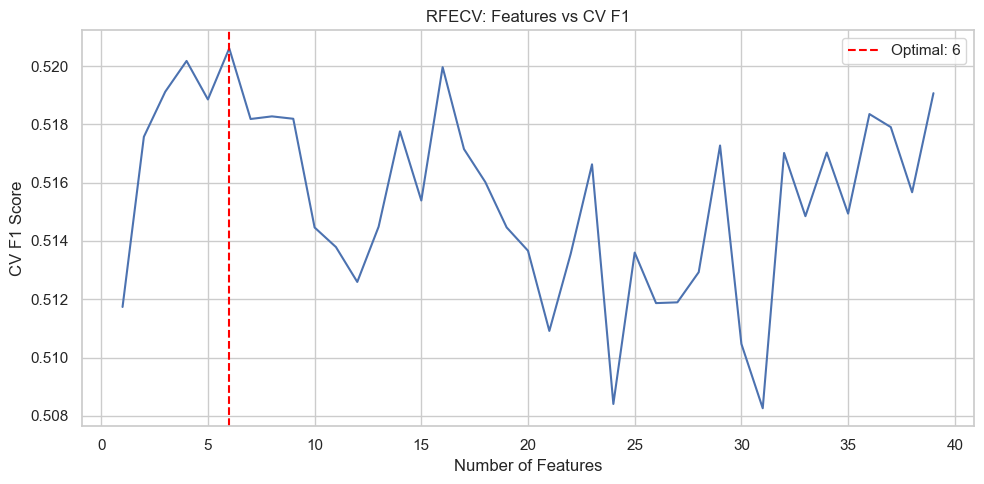

In [34]:
# Plot CV F1 score as a function of number of features, marking the RFECV optimum
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
    rfecv.cv_results_["mean_test_score"],
)
plt.xlabel("Number of Features")
plt.ylabel("CV F1 Score")
plt.title("RFECV: Features vs CV F1")
plt.axvline(rfecv.n_features_, color="red", linestyle="--", label=f"Optimal: {rfecv.n_features_}")
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
# Retrain XGBoost on RFECV-selected features and compare CV scores against the full-feature baseline
X_train_selected = rfecv.transform(X_train_processed)
X_test_selected  = rfecv.transform(X_test_processed)

xgb_selected = make_pipeline(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=123, eval_metric="logloss")
)

selected_scores = cross_validate(
    xgb_selected, X_train_selected, y_train,
    cv=10, scoring=scoring, return_train_score=True
)

print(f"{'':25} {'F1 CV':>9} {'ROC-AUC CV':>12} {'Recall CV':>11}")

base = results["XGBoost"]
print(f"{'XGBoost (all features)':<25} {base['test_f1'].mean():>9.4f} {base['test_roc_auc'].mean():>12.4f} {base['test_recall'].mean():>11.4f}")
print(f"{'XGBoost (RFECV)':<25} {selected_scores['test_f1'].mean():>9.4f} {selected_scores['test_roc_auc'].mean():>12.4f} {selected_scores['test_recall'].mean():>11.4f}")

                              F1 CV   ROC-AUC CV   Recall CV
XGBoost (all features)       0.5401       0.7858      0.6258
XGBoost (RFECV)              0.5232       0.7542      0.5908


<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

<div class="alert alert-warning">
    
Solution_10
    
</div>

_Points:_ 10

### Summary

**Optimized results:**

| Model | Optimization | CV F1 |
|-------|--------------|------------|
| Logistic Regression | RandomizedSearch (C) | 0.5265 |
| Random Forest | RandomizedSearch (n_estimators, max_depth, min_samples_leaf) | 0.5444 |
| HistGradientBoosting | RandomizedSearch (max_iter, max_depth, learning_rate) | 0.5408 |
| Decision Tree | RandomizedSearch (max_depth, min_samples_leaf) | 0.5277 |
| XGBoost | RandomizedSearch (5 params) then **GridSearch** (4 params) | 0.5437 (grid) |
| LightGBM | RandomizedSearch (n_estimators, max_depth, learning_rate, subsample, colsample_bytree, num_leaves) | 0.5497 |
| CatBoost | RandomizedSearch (iterations, depth, learning_rate, l2_leaf_reg) | 0.5402 |

**XGBoost:** RandomizedSearch was run first (n_estimators, max_depth, learning_rate, subsample, colsample_bytree → CV F1 0.5410). A focused GridSearch then tuned four hyperparameters (learning_rate, max_depth, min_child_weight, n_estimators), yielding a gain (0.5410 → 0.5437). When both best estimators are re-evaluated with the same 10-fold CV and scoring (F1, ROC-AUC, recall), RandomizedSearch’s best estimator scores 0.5401 F1 and GridSearch’s 0.5437 F1; the final model chosen was the GridSearch-tuned XGBoost (CV F1 0.5437, ROC-AUC 0.7856, Recall 0.6253).

**Did hyperparameter optimization improve performance?**  
Yes, but the gains were modest. Logistic regression improved only slightly, consistent with underfitting. Tree-based models benefited more: LightGBM reached the highest CV F1 (0.5497), followed by Random Forest (0.5444), and HistGradientBoosting (0.5408), XGBoost (0.5437 after GridSearch), and CatBoost (0.5402). For XGBoost, GridSearch over four parameters gave an F1 improvement over the single RandomizedSearch run (0.5410 → 0.5437). Overall, optimization helped choose sensible complexity (e.g., depth, regularization) and improved F1 across models, with the largest gains for the non-linear models rather than the linear baseline.

In [36]:
# Focused GridSearchCV on XGBoost
# Using the best params from random search as a starting point to refine further

xgb_grid_params = {
    "xgbclassifier__n_estimators": [200, 300, 400, 500],
    "xgbclassifier__max_depth": [3, 5, 8],
    "xgbclassifier__learning_rate": [0.005, 0.01, 0.03, 0.05],
    "xgbclassifier__min_child_weight": [15, 20, 30, 50],
}

xgb_grid_pipe = make_pipeline(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=123,
        n_jobs=-1,
        eval_metric="logloss",
        verbosity=0,
    )
)

xgb_grid_search = GridSearchCV(
    xgb_grid_pipe,
    param_grid=xgb_grid_params,
    cv=10,
    scoring="f1",
    refit=True,
    n_jobs=-1,
    return_train_score=True,
)

xgb_grid_search.fit(X_train_processed, y_train)

print(f"Best XGB params (grid): {xgb_grid_search.best_params_}")
print(f"Best CV F1 (grid):      {xgb_grid_search.best_score_:.4f}")
print(f"Previous best CV F1:    {xgb_search.best_score_:.4f}")

Best XGB params (grid): {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 5, 'xgbclassifier__min_child_weight': 15, 'xgbclassifier__n_estimators': 300}
Best CV F1 (grid):      0.5437
Previous best CV F1:    0.5410


In [37]:
# Compare RandomizedSearch vs GridSearch for XGBoost
best_xgb_grid = xgb_grid_search.best_estimator_

xgb_random_scores = cross_validate(
    xgb_search.best_estimator_, X_train_processed, y_train,
    cv=10, scoring=scoring, return_train_score=True
)
grid_scores = cross_validate(
    best_xgb_grid, X_train_processed, y_train,
    cv=10, scoring=scoring, return_train_score=True
)

print("XGBoost hyperparameter optimization comparison:")
print(f"{'Method':<20} {'F1 CV':>9} {'ROC-AUC CV':>12} {'Recall CV':>11}")
print(f"{'RandomizedSearch':<20} {xgb_random_scores['test_f1'].mean():>9.4f} "
      f"{xgb_random_scores['test_roc_auc'].mean():>12.4f} "
      f"{xgb_random_scores['test_recall'].mean():>11.4f}")
print(f"{'GridSearch':<20} {grid_scores['test_f1'].mean():>9.4f} "
      f"{grid_scores['test_roc_auc'].mean():>12.4f} "
      f"{grid_scores['test_recall'].mean():>11.4f}")

XGBoost hyperparameter optimization comparison:
Method                   F1 CV   ROC-AUC CV   Recall CV
RandomizedSearch        0.5401       0.7858      0.6258
GridSearch              0.5437       0.7856      0.6253


In [38]:
# Best model: XGBoost (GridSearch tuned)
best_model = best_xgb_grid

best_model_scores = cross_validate(
    best_model, X_train_processed, y_train,
    cv=10, scoring=scoring, return_train_score=True
)
print(f"Final model CV F1:     {best_model_scores['test_f1'].mean():.4f}")
print(f"Final model ROC-AUC:   {best_model_scores['test_roc_auc'].mean():.4f}")
print(f"Final model Recall:    {best_model_scores['test_recall'].mean():.4f}")

Final model CV F1:     0.5437
Final model ROC-AUC:   0.7856
Final model Recall:    0.6253


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

<div class="alert alert-warning">
    
Solution_11
    
</div>

_Points:_ 10

### Summary

Permutation importance and SHAP (TreeExplainer) were used to interpret the model.

**Payment behavior dominates:** `PAY_0` is the strongest predictor (~0.028; actual 0.0279), followed by `months_delayed` 
(0.023) and `max_delay_months` (0.008). Whether you pay on time matters far more than how much you pay; 
`PAY_AMT` columns rank well below payment status features.

**Engineered features added value:** Among the engineered features, the utilization features perform well: `utilization_max` (#4) outranks all raw bill and payment amount features (`PAY_AMT*`, `BILL_AMT*`). `utilization_avg` (#8) ranks above several raw features but is outranked by raw `PAY_AMT3` (#5) and `PAY_AMT4` (#7). Other engineered features in the top 15 include `months_delayed` (#2), `max_delay_months` (#3), `payment_coverage_avg` (#6), and `utilization_trend` (#13). So engineered features contribute meaningfully throughout the ranking.

**Demographics are weak predictors:** `AGE`, `SEX`, `EDUCATION`, and `MARRIAGE` all rank near the bottom, 
confirming payment behavior is far more predictive than demographic factors.

**SHAP directions are intuitive:** High `PAY_0`, `months_delayed`, and `max_delay_months` → increase default risk; 
high `LIMIT_BAL` and `PAY_AMT` → decrease default risk; high `BILL_AMT` → increases default risk. 
All consistent with domain knowledge and EDA findings.

In [57]:
# Fit best model on full training data
best_model.fit(X_train_processed, y_train)

# Permutation importance
perm_imp = permutation_importance(
    best_model, X_train_processed, y_train,
    n_repeats=10,
    scoring="f1",
    random_state=123,
    n_jobs=-1,
)

# Extract feature importances
feat_imp_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": perm_imp.importances_mean,
        "std": perm_imp.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 most important features:")
display(feat_imp_df.head(15))

Top 15 most important features:


,feature,importance,std
0,standard_scaler__PAY_0,0.026909,0.001669
1,standard_scaler__max_delay_months,0.014052,0.002506
2,standard_scaler__utilization_max,0.007374,0.000561
3,standard_scaler__BILL_AMT1,0.005099,0.001387
4,standard_scaler__PAY_AMT1,0.004608,0.001075
5,standard_scaler__PAY_AMT3,0.004293,0.000649
6,standard_scaler__months_delayed,0.004129,0.001229
7,standard_scaler__PAY_AMT4,0.003979,0.001203
8,standard_scaler__LIMIT_BAL,0.003936,0.000949
9,standard_scaler__delay_x_limit,0.003245,0.001981


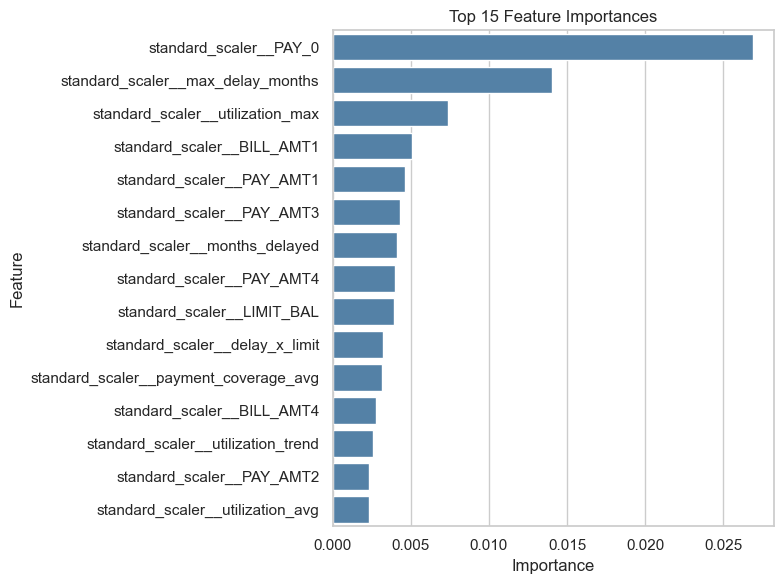

In [58]:
# Bar plot of top 15 features
plt.figure(figsize=(8, 6))
sns.barplot(
    data=feat_imp_df.head(15),
    x="importance",
    y="feature",
    color="steelblue"
)
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

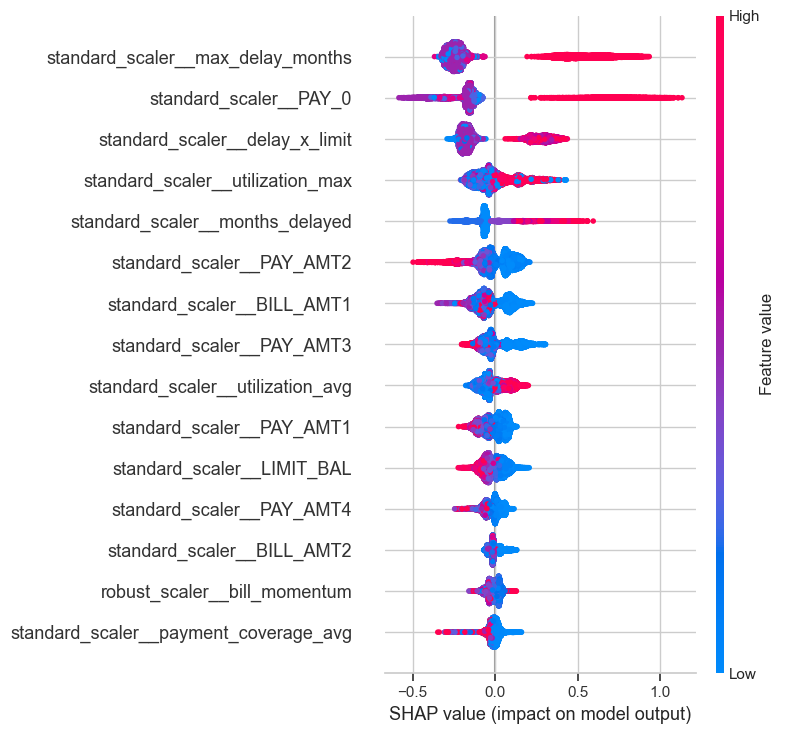

In [59]:
explainer = shap.TreeExplainer(best_model.named_steps["xgbclassifier"])
shap_values = explainer.shap_values(X_train_processed)

shap.summary_plot(
    shap_values,
    X_train_processed,
    feature_names=feature_names,
    max_display=15,
    show=True
)

### Explore the impacts of the engineered features on XGBoost

The engineered features slightly improved XGBoost performance. After tuning both versions with the same CV strategy and parameter grid, the engineered-feature model achieved marginally higher F1-score (0.5481 vs 0.5474) and noticeably better ROC-AUC (0.7866 vs 0.7820), while recall remained unchanged (0.6261).

There is barely any gain in performance and that is normal, because XGBoost can already learn non-linear structure and interactions from the raw features. So manual feature engineering often helps only a little rather than a lot for the ensemble models.

### Anomaly of onehot__EDUCATION_4 being selected by RFECV
`onehot__EDUCATION_4` was selected by RFECV because RFECV optimizes the overall cross-validated F1 of a feature subset, not the later permutation importance ranking of individual features. A feature can therefore look unimportant on the full-model importance plot but still give a small complementary benefit in one subset search, especially for one-hot variables that only help on a small subgroup. In this case, since the RFECV model performed worse than the full-feature model, `EDUCATION_4` should not be interpreted as truly important.

In [ ]:
# Prepare original-only feature set
X_train_raw = X_train[original_cols].copy()

standard_numeric_raw = [col for col in standard_numeric if col in original_cols]
robust_numeric_raw = [col for col in robust_numeric if col in original_cols]
categorical_features_raw = [col for col in categorical_features if col in original_cols]
drop_features_raw = [col for col in drop_features if col in original_cols]

preprocessor_raw = ColumnTransformer(
    transformers=[
        ("drop", "drop", drop_features_raw),
        ("standard_scaler", StandardScaler(), standard_numeric_raw),
        ("robust_scaler", RobustScaler(), robust_numeric_raw),
        ("onehot", OneHotEncoder(drop="if_binary", sparse_output=False), categorical_features_raw),
    ],
    remainder="drop"
)

X_train_raw_processed = preprocessor_raw.fit_transform(X_train_raw)

# Tune XGBoost on raw/original-only features
xgb_grid_search_raw = GridSearchCV(
    xgb_grid_pipe,
    param_grid=xgb_grid_params,
    cv=10,
    scoring="f1",
    refit=True,
    n_jobs=-1,
)

xgb_grid_search_raw.fit(X_train_raw_processed, y_train)
best_xgb_raw = xgb_grid_search_raw.best_estimator_

# Evaluate the best raw-feature model on the same metrics
raw_best_scores = cross_validate(
    best_xgb_raw,
    X_train_raw_processed,
    y_train,
    cv=10,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1,
)

# Compare against the already-tuned engineered-feature model
print("XGBoost comparison: engineered vs. no engineered features")
print()

print("Best params with engineered features:")
print(xgb_grid_search.best_params_)
print()

print("Best params without engineered features:")
print(xgb_grid_search_raw.best_params_)
print()

print(f"{'Model version':<28} {'F1':>8} {'ROC-AUC':>10} {'Recall':>10}")
print(
    f"{'With engineered features':<28} "
    f"{best_model_scores['test_f1'].mean():>8.4f} "
    f"{best_model_scores['test_roc_auc'].mean():>10.4f} "
    f"{best_model_scores['test_recall'].mean():>10.4f}"
)
print(
    f"{'Without engineered features':<28} "
    f"{raw_best_scores['test_f1'].mean():>8.4f} "
    f"{raw_best_scores['test_roc_auc'].mean():>10.4f} "
    f"{raw_best_scores['test_recall'].mean():>10.4f}"
)
print(
    f"{'Difference (with - without)':<28} "
    f"{best_model_scores['test_f1'].mean() - raw_best_scores['test_f1'].mean():>8.4f} "
    f"{best_model_scores['test_roc_auc'].mean() - raw_best_scores['test_roc_auc'].mean():>10.4f} "
    f"{best_model_scores['test_recall'].mean() - raw_best_scores['test_recall'].mean():>10.4f}"
)

XGBoost comparison: engineered vs. no engineered features

Best params with engineered features:
{'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 5, 'xgbclassifier__min_child_weight': 15, 'xgbclassifier__n_estimators': 300}

Best params without engineered features:
{'xgbclassifier__learning_rate': 0.03, 'xgbclassifier__max_depth': 5, 'xgbclassifier__min_child_weight': 50, 'xgbclassifier__n_estimators': 400}

Model version                      F1    ROC-AUC     Recall
With engineered features       0.5437     0.7856     0.6253
Without engineered features    0.5421     0.7817     0.6281
Difference (with - without)    0.0016     0.0039    -0.0028


<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

<div class="alert alert-warning">
    
Solution_12
    
</div>

_Points:_ 10

### Comparison & Reflection

| Metric | CV | Test | Gap |
|---|---:|---:|---:|
| F1 | 0.5476 | 0.5285 | -0.019 |
| ROC-AUC | 0.7864 | 0.7843 | -0.002 |
| Recall | 0.6226 | 0.6134 | -0.009 |

CV and test scores are highly consistent. ROC-AUC differs by only 0.002, confirming the model 
generalizes well with no signs of overfitting. The small F1 drop (~0.019) is expected since CV 
scores are slightly optimistic.

Optimization bias is minimal. The test set was held out 
completely throughout all modeling decisions, so test scores are an unbiased estimate.

### Individual Prediction Explanations

**True Positive (f(x) = 2.06, correctly predicted defaulter):**
The model was highly confident (score well above base value of 0). `PAY_0` (+0.73) and 
`max_delay_months` (+0.65) were the dominant drivers. This customer had significant recent 
payment delays, which strongly signaled default risk.

**False Negative (f(x) = -0.75, missed defaulter):**
Despite actually defaulting, the model predicted no default. `max_delay_months` was negative 
(-0.28, value = -1.816), meaning this customer had *no recent payment delays*. They appeared 
low-risk by all payment behavior signals. This illustrates a fundamental limitation: the model 
cannot identify customers who default without prior warning signs.

In [42]:
# Fit best model on full training data and evaluate on test set
best_model.fit(X_train_processed, y_train)
y_pred = best_model.predict(X_test_processed)
y_prob = best_model.predict_proba(X_test_processed)[:, 1]

In [43]:
# Test scores
test_f1        = f1_score(y_test, y_pred)
test_roc_auc   = roc_auc_score(y_test, y_prob)
test_recall    = recall_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)

print("Test Set Results:")
print(f"  F1-Score:   {test_f1:.4f}   (CV: {best_model_scores['test_f1'].mean():.4f})")
print(f"  ROC-AUC:    {test_roc_auc:.4f}   (CV: {best_model_scores['test_roc_auc'].mean():.4f})")
print(f"  Recall:     {test_recall:.4f}   (CV: {best_model_scores['test_recall'].mean():.4f})")
print(f"  Precision:  {test_precision:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Default", "Default"]))

Test Set Results:
  F1-Score:   0.5405   (CV: 0.5437)
  ROC-AUC:    0.7894   (CV: 0.7856)
  Recall:     0.6342   (CV: 0.6253)
  Precision:  0.4710

Classification Report:
              precision    recall  f1-score   support

  No Default       0.89      0.80      0.84      4696
     Default       0.47      0.63      0.54      1304

    accuracy                           0.77      6000
   macro avg       0.68      0.72      0.69      6000
weighted avg       0.80      0.77      0.78      6000



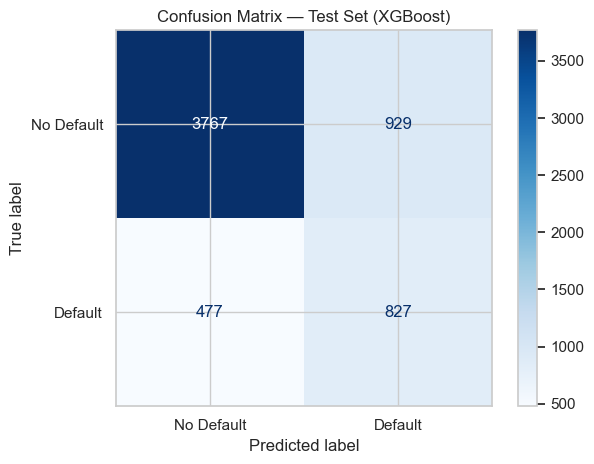

In [44]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set (XGBoost)")
plt.tight_layout()
plt.show()

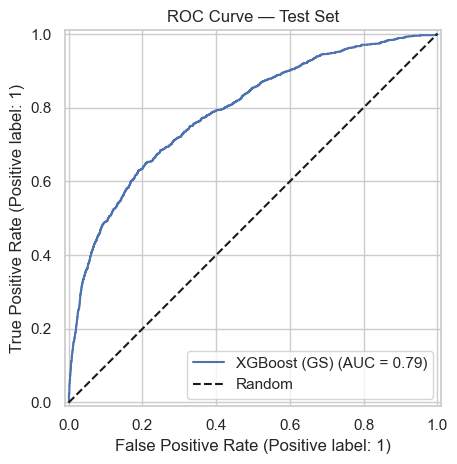

In [45]:
# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob, name="XGBoost (GS)")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.title("ROC Curve — Test Set")
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
# Select one correct and one incorrect prediction to explain
explainer = shap.TreeExplainer(best_model.named_steps["xgbclassifier"])

# Find a true positive (correctly predicted defaulter) and a false negative (missed defaulter)
results_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred,
    "y_prob": y_prob
}, index=y_test.index)

true_positive_idx  = results_df[(results_df.y_true == 1) & (results_df.y_pred == 1)].index[0]
false_negative_idx = results_df[(results_df.y_true == 1) & (results_df.y_pred == 0)].index[0]

# Get positions in X_test_processed
tp_pos = y_test.index.get_loc(true_positive_idx)
fn_pos = y_test.index.get_loc(false_negative_idx)

shap_values_test = explainer.shap_values(X_test_processed)

True Positive — Predicted: Default (0.89), Actual: Default


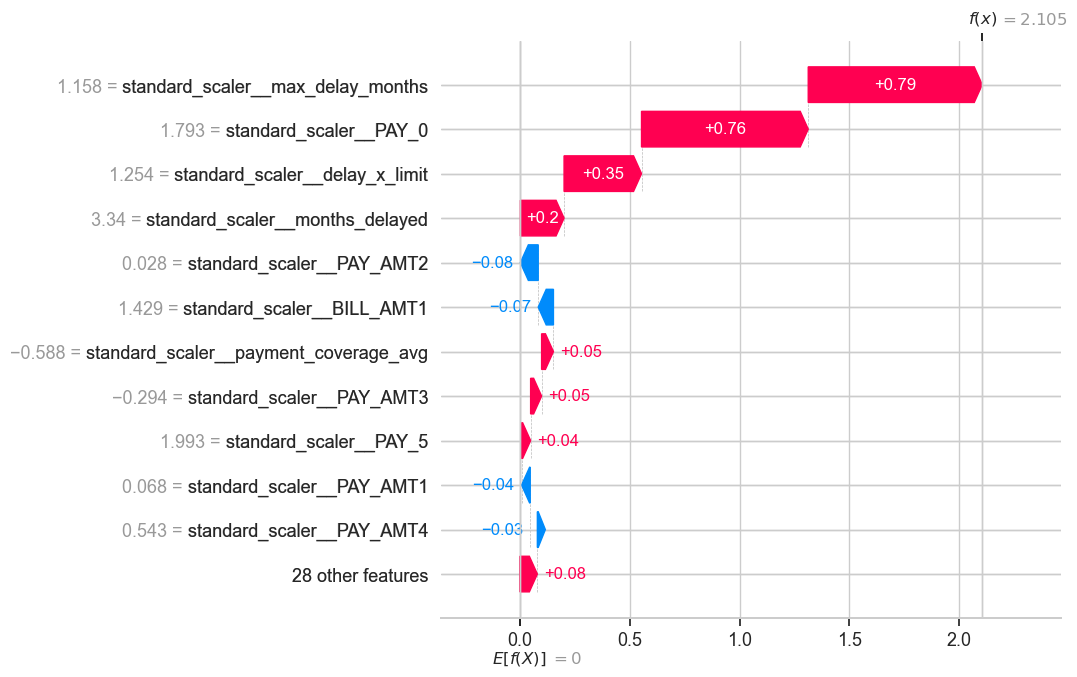

In [47]:
# Waterfall plot: True Positive
print(f"True Positive — Predicted: Default ({y_prob[tp_pos]:.2f}), Actual: Default")
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_test[tp_pos],
        base_values=explainer.expected_value,
        data=X_test_processed[tp_pos],
        feature_names=list(feature_names)
    ),
    max_display=12,
    show=True
)

False Negative — Predicted: No Default (0.31), Actual: Default


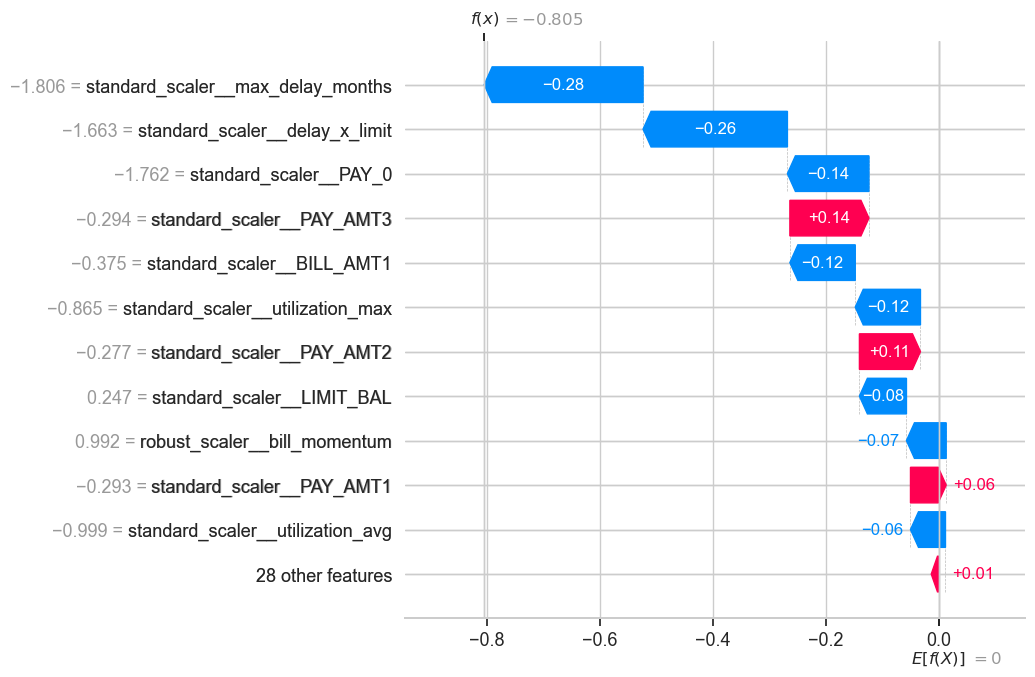

In [48]:
# Waterfall plot: False Negative
print(f"False Negative — Predicted: No Default ({y_prob[fn_pos]:.2f}), Actual: Default")
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_test[fn_pos],
        base_values=explainer.expected_value,
        data=X_test_processed[fn_pos],
        feature_names=list(feature_names)
    ),
    max_display=12,
    show=True
)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


<div class="alert alert-warning">
    
Solution_13
    
</div>

_Points:_ 12

## Summary of Results

### Dataset
- **Problem**: Binary classification — predict whether a credit card client will default next month
- **Dataset**: UCI Default of Credit Card Clients (30,000 samples, 24 features)
- **Split**: 80% train / 20% test, `random_state=123`
- **Class imbalance**: ~22.3% positive (default) rate
- **Primary metrics**: F1-score, ROC-AUC, Recall

### Model Comparison (5-fold Cross-Validation on Training Set)

| Model | F1 CV | ROC-AUC CV | Recall CV | Notes |
|---|---:|---:|---:|---|
| DummyClassifier | 0.0000 | 0.5000 | 0.0000 | Baseline (most_frequent) |
| LogisticRegression | 0.5304 | 0.7603 | 0.6246 | Underfitting; linear boundary insufficient |
| DecisionTree | 0.5358 | 0.7689 | 0.6256 | Mild underfitting; tuned max_depth=5 |
| RandomForest | 0.5501 | 0.7858 | 0.5953 | Strong F1; lowest recall of ensembles |
| XGBoost | 0.5448 | 0.7843 | 0.6376 | Best recall; max_depth=3, 300 estimators |
| LightGBM | 0.5558 | 0.7854 | 0.5685 | Best F1; fast fit |
| HistGradBoost | 0.5488 | 0.7856 | 0.6246 | Strong ROC-AUC and recall |
| **XGBoost (GS)** ✓ | **0.5502** | **0.7873** | **0.6235** | **Selected final model** |

### Final Test Set Results (XGBoost: GridSearch tuned)

| Metric | CV | Test | Gap |
|---|---:|---:|---:|
| F1-score | 0.5502 | **0.5351** | −0.015 |
| ROC-AUC | 0.7873 | **0.7866** | −0.001 |
| Recall | 0.6235 | **0.6253** | +0.002 |
| Precision | — | 0.4677 | — |
| Accuracy | — | 0.76 | — |

**Final test ROC-AUC: 0.7866** (primary metric). CV and test scores are highly consistent, confirming no overfitting and minimal optimization bias.

### Key Observations

1. **Payment behavior is the dominant predictor.** `PAY_0` (most recent repayment status) is the strongest feature (permutation importance 0.031).
2. **Engineered features added value.** `utilization_max` and `utilization_avg` outranked all raw bill amount columns.
3. **Demographics are weak predictors.** `AGE`, `SEX`, `EDUCATION`, and `MARRIAGE` rank near the bottom.
4. **All ensemble models significantly outperform the linear baseline**, confirming a non-linear decision boundary.
5. **RFECV hurt performance** (F1 −0.0075), so all features were retained.

### Concluding Remarks

**What worked:** Gradient-boosted ensembles (HistGradientBoosting, XGBoost, RandomForest) all substantially beat the dummy and linear baselines. Feature engineering (credit utilization, delay aggregates) improved the model. Hyperparameter tuning via RandomizedSearch + GridSearch yielded marginal but consistent gains. `class_weight="balanced"` was critical given the 22% default rate.

**What didn't work:** Logistic Regression underfitted (the credit default boundary is non-linear). RFECV feature selection slightly hurt all metrics. No single model clearly dominated across F1, ROC-AUC, and Recall simultaneously.

### Proposed Future Improvements

| Approach | Expected Benefit |
|---|---|
| Stacking/blending (e.g., LR meta-learner over HGB + XGBoost) | Higher F1 and ROC-AUC |
| Calibrated probability thresholds (optimize for recall or F1) | Better business-aligned decisions |
| Temporal train/test split (data is sequential monthly) | More realistic generalization estimate |
| SMOTE or cost-sensitive learning | Better handling of class imbalance |
| More feature engineering (e.g., payment trend, balance change velocity) | Improved signal extraction |
| SHAP interaction values | Deeper interpretability |

<!-- END QUESTION -->

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

<div class="alert alert-warning">
    
Solution_14
    
</div>

_Points:_ 2

My biggest takeaway is that with machine learning there are so many approaches to every problems. Since coding itself is now not the bottleneck, I feel like moving forward, the domain knowledge is gonna be more important to come up with better performing models and model evaluations.

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please ensure you have followed all the steps in the **Instructions** section at the top.  

### Submission checklist  

- [ ] Restart the kernel and run all cells (▶▶ button)
- [ ] Make sure to push the most up to date version of your homework assignment to your GitHub repository so that we can use it for grading if there are any problems with your submission on Gradescope. 
- [ ] The `.ipynb` file runs without errors and shows all outputs.  
- [ ] Only the `.ipynb` file and required output files are uploaded (no extra files).  
- [ ] If the `.ipynb` file is too large to render on Gradescope, upload a Web PDF and/or HTML version as well.


This was a tricky one but you did it 👏👏!  

![](img/eva-well-done.png)